# 🧹 NyayaAuth — Preprocessing Pipeline (Google Colab)

This notebook:
1. Reads raw data from `MyDrive/NyayaAuth/data/raw/`
2. Fixes duplicate columns, cleans and lemmatizes text
3. Augments small datasets to get enough samples
4. Encodes IPC labels, computes class weights
5. Saves train/val/test splits to `MyDrive/NyayaAuth/data/processed/`

---
> **Run cells top to bottom. Do not skip any cell.**

## Cell 1 — Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT_DIR = "/content/drive/MyDrive/NyayaAuth"
RAW_DIR     = f"{PROJECT_DIR}/data/raw"
OUT_DIR     = f"{PROJECT_DIR}/data/processed"

os.makedirs(OUT_DIR, exist_ok=True)

print("✅ Google Drive mounted")
print(f"   Raw data dir : {RAW_DIR}")
print(f"   Output dir   : {OUT_DIR}")

# Show what raw files exist
print("\n📂 Files found in raw/:")
for root, dirs, files in os.walk(RAW_DIR):
    for f in files:
        fpath = os.path.join(root, f)
        size  = os.path.getsize(fpath) / 1024
        print(f"   {f:45s} {size:8.1f} KB")

Mounted at /content/drive
✅ Google Drive mounted
   Raw data dir : /content/drive/MyDrive/NyayaAuth/data/raw
   Output dir   : /content/drive/MyDrive/NyayaAuth/data/processed

📂 Files found in raw/:
   ipc_data.csv                                     358.9 KB
   class_distribution.png                            65.2 KB
   IPC_section_data.csv                              37.0 KB
   FIR_DATASET.csv                                  452.0 KB
   crime_dataset_india.csv                         4827.7 KB
   crime_reports_hf.csv                           41045.3 KB
   ipc_sections_hf.csv                              399.8 KB


## Cell 2 — Install dependencies

In [2]:
!pip install nltk scikit-learn pandas numpy joblib tqdm -q

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

print("✅ All dependencies ready")

✅ All dependencies ready


## Cell 3 — Load ALL raw CSV files from the directory

In [3]:
import pandas as pd
import os

# ── COLUMN NAME MAPPING ─────────────────────────────────
# Maps any known column variation → standard name
COLUMN_MAPS = {
    # Description variations
    "offense":             "description",
    "Offense":             "description",
    "crime_description":   "description",
    "Description":         "description",
    "text":                "description",
    "crime":               "description",
    "fir_text":            "description",
    "case_description":    "description",
    "details":             "description",
    "Punishment":          "description",
    "punishment":          "description",
    "offense_description": "description",
    "content":             "description",
    "sentence":            "description",
    # IPC section variations
    "section":             "ipc_section",
    "Section":             "ipc_section",
    "ipc_section":         "ipc_section",
    "IPC_Section":         "ipc_section",
    "IPC Section":         "ipc_section",
    "ipc":                 "ipc_section",
    "label":               "ipc_section",
    "category":            "ipc_section",
    "crime_type":          "ipc_section",
    "charge":              "ipc_section",
    "Chapter":             "ipc_section",
    "chapter":             "ipc_section",
    "class":               "ipc_section",
}
# ────────────────────────────────────────────────────────

all_dfs = []
skipped = []

for root, dirs, files in os.walk(RAW_DIR):
    for fname in files:
        if not fname.endswith((".csv", ".xlsx", ".json")):
            continue
        fpath = os.path.join(root, fname)
        try:
            if fname.endswith(".csv"):
                df_raw = pd.read_csv(fpath, on_bad_lines='skip')
            elif fname.endswith(".xlsx"):
                df_raw = pd.read_excel(fpath)
            else:
                df_raw = pd.read_json(fpath)

            # Rename columns
            df_raw = df_raw.rename(columns=COLUMN_MAPS)

            # Drop duplicate description columns (description.1, description.2 etc)
            drop_cols = [c for c in df_raw.columns
                         if c.startswith("description.") or c.startswith("ipc_section.")]
            df_raw = df_raw.drop(columns=drop_cols, errors='ignore')

            if "description" in df_raw.columns and "ipc_section" in df_raw.columns:
                subset = df_raw[["description", "ipc_section"]].copy()
                subset["source"] = fname
                subset = subset.dropna()
                subset = subset[subset["description"].astype(str).str.strip() != ""]
                subset = subset[subset["ipc_section"].astype(str).str.strip() != ""]
                all_dfs.append(subset)
                print(f"✅ {fname:50s} → {len(subset):>5} rows  | cols: {list(df_raw.columns)}")
            else:
                skipped.append((fname, list(df_raw.columns)))
                print(f"⚠️  SKIPPED {fname}")
                print(f"   Columns: {list(df_raw.columns)}")
                print(f"   → Add mapping in COLUMN_MAPS above")

        except Exception as e:
            print(f"❌ Error reading {fname}: {e}")

print(f"\nLoaded {len(all_dfs)} file(s) | Skipped {len(skipped)} file(s)")

✅ ipc_data.csv                                       →   384 rows  | cols: ['description', 'ipc_section', 'source']
⚠️  SKIPPED IPC_section_data.csv
   Columns: ['First_Column', 'Second_Column']
   → Add mapping in COLUMN_MAPS above
⚠️  SKIPPED FIR_DATASET.csv
   Columns: ['URL', 'description', 'description', 'description', 'Cognizable', 'Bailable', 'Court']
   → Add mapping in COLUMN_MAPS above
⚠️  SKIPPED crime_dataset_india.csv
   Columns: ['Report Number', 'Date Reported', 'Date of Occurrence', 'Time of Occurrence', 'City', 'Crime Code', 'Crime Description', 'Victim Age', 'Victim Gender', 'Weapon Used', 'Crime Domain', 'Police Deployed', 'Case Closed', 'Date Case Closed']
   → Add mapping in COLUMN_MAPS above
⚠️  SKIPPED crime_reports_hf.csv
   Columns: ['ipc_section', 'sub_category', 'crimeaditionalinfo']
   → Add mapping in COLUMN_MAPS above
❌ Error reading ipc_sections_hf.csv: 'DataFrame' object has no attribute 'str'

Loaded 1 file(s) | Skipped 4 file(s)


## Cell 4 — Merge and inspect raw combined data

In [4]:
if len(all_dfs) == 0:
    raise ValueError("❌ No datasets loaded! Fix COLUMN_MAPS in Cell 3 and re-run.")

df = pd.concat(all_dfs, ignore_index=True)
print(f"Total rows (before dedup) : {len(df)}")

df["description"] = df["description"].astype(str).str.strip()
df["ipc_section"] = (
    df["ipc_section"].astype(str)
    .str.strip().str.upper()
    .str.replace(r"\s+", " ", regex=True)
)

# Remove duplicates
df = df.drop_duplicates(subset=["description"]).reset_index(drop=True)
print(f"Total rows (after dedup)  : {len(df)}")
print(f"Unique IPC sections       : {df['ipc_section'].nunique()}")
print(f"Sources                   : {df['source'].unique().tolist()}")
print()
display(df.head(5))
print()

# Show top 10 IPC sections
print("Top 10 IPC sections by count:")
display(df['ipc_section'].value_counts().head(10).to_frame('count'))

Total rows (before dedup) : 384
Total rows (after dedup)  : 384
Unique IPC sections       : 384
Sources                   : ['ipc_data.csv']



,description,ipc_section,source
0,Description of IPC Section 140 According to se...,IPC_140,ipc_data.csv
1,Description of IPC Section 127 According to se...,IPC_127,ipc_data.csv
2,Description of IPC Section 128 According to se...,IPC_128,ipc_data.csv
3,Description of IPC Section 129 According to se...,IPC_129,ipc_data.csv
4,Description of IPC Section 130 According to se...,IPC_130,ipc_data.csv



Top 10 IPC sections by count:


,count
ipc_section,
IPC_472,1
IPC_473,1
IPC_474,1
IPC_475,1
IPC_476,1
IPC_477,1
IPC_477A,1
IPC_482,1
IPC_461,1


## Cell 5 — Smart augmentation (expands small datasets)
Since the public datasets are small, this cell creates clean variations of each sample so every IPC section has enough examples to train and evaluate on.

In [5]:
import random
import re
random.seed(42)

def augment_text(text, variant):
    """Create clean variations of a description without changing meaning."""
    words = str(text).split()
    if len(words) < 4:
        return text
    if variant == 1:
        return " ".join(words[1:])           # remove first word
    elif variant == 2:
        return " ".join(words[:-1])          # remove last word
    elif variant == 3:
        mid = len(words) // 2
        return " ".join(words[mid:])         # second half
    elif variant == 4:
        return " ".join(words[::-1][:len(words)//2 + 1])  # partial reverse
    return text

# Decide how many augmented copies per sample based on dataset size
original_size  = len(df)
TARGET_SAMPLES = 5000   # aim for this many total samples minimum

if original_size >= TARGET_SAMPLES:
    copies_needed = 1
elif original_size >= 1000:
    copies_needed = 3
else:
    copies_needed = 5

print(f"Original samples   : {original_size}")
print(f"Augmentation copies: {copies_needed} per sample")

aug_rows = []
for _, row in df.iterrows():
    aug_rows.append({"description": row["description"],
                     "ipc_section": row["ipc_section"]})
    for v in range(1, copies_needed + 1):
        aug_text = augment_text(row["description"], v)
        if aug_text.strip() and aug_text != row["description"]:
            aug_rows.append({"description": aug_text,
                             "ipc_section": row["ipc_section"]})

df_aug = pd.DataFrame(aug_rows).drop_duplicates(subset=["description"]).reset_index(drop=True)

print(f"Augmented samples  : {len(df_aug)}")
print(f"IPC sections       : {df_aug['ipc_section'].nunique()}")
display(df_aug.head(5))

Original samples   : 384
Augmentation copies: 5 per sample
Augmented samples  : 1920
IPC sections       : 384


,description,ipc_section
0,Description of IPC Section 140 According to se...,IPC_140
1,of IPC Section 140 According to section 140 of...,IPC_140
2,Description of IPC Section 140 According to se...,IPC_140
3,"for a term which may extend to three months, o...",IPC_140
4,"both. or rupees, hundred five to up of fine a ...",IPC_140


## Cell 6 — Clean and preprocess text
Applies legal-aware stopword removal, lemmatization, and normalization — exactly as described in your paper.

In [6]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from tqdm import tqdm
tqdm.pandas()

# Legal terms to preserve (never remove these)
LEGAL_KEEP = {
    "not", "no", "without", "against", "under", "above", "below",
    "between", "within", "with", "intent", "force", "death", "bodily",
    "harm", "injury", "weapon", "accused", "victim", "complainant",
    "abetment", "attempt", "theft", "murder", "assault", "robbery",
    "fraud", "cheating", "hurt", "kidnap", "rape", "abduction",
    "criminal", "offense", "offence", "guilty", "punish", "liable"
}

GENERIC_STOPS = set(stopwords.words("english")) - LEGAL_KEEP
lemmatizer    = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"section\s+\d+[a-z]?", "", text)  # remove "section 302"
    text = re.sub(r"\bipc\b|\bcrpc\b|\bbns\b", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)             # keep only letters
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [
        lemmatizer.lemmatize(t)
        for t in text.split()
        if t not in GENERIC_STOPS and len(t) > 2
    ]
    return " ".join(tokens)

print("Cleaning texts (this may take a minute)...")
df_aug["clean_text"] = df_aug["description"].progress_apply(clean_text)

# Drop rows where cleaning produced empty text
before = len(df_aug)
df_aug = df_aug[df_aug["clean_text"].str.strip().str.len() > 5].reset_index(drop=True)
print(f"Dropped {before - len(df_aug)} empty rows after cleaning")

lengths = df_aug["clean_text"].str.split().apply(len)
print(f"\n✅ Text cleaning complete!")
print(f"   Total samples        : {len(df_aug)}")
print(f"   Avg words per sample : {lengths.mean():.1f}")
print(f"   Min words            : {lengths.min()}")
print(f"   Max words            : {lengths.max()}")

# Show before vs after
print("\nBefore vs After cleaning:")
for i in range(3):
    print(f"\n  BEFORE: {df_aug['description'].iloc[i][:100]}")
    print(f"  AFTER : {df_aug['clean_text'].iloc[i][:100]}")

Cleaning texts (this may take a minute)...


100%|██████████| 1920/1920 [00:07<00:00, 263.06it/s] 


Dropped 0 empty rows after cleaning

✅ Text cleaning complete!
   Total samples        : 1920
   Avg words per sample : 58.5
   Min words            : 6
   Max words            : 246

Before vs After cleaning:

  BEFORE: Description of IPC Section 140 According to section 140 of Indian penal code, Whoever, not being a s
  AFTER : description according indian penal code whoever not soldier sailor airman military naval air service

  BEFORE: of IPC Section 140 According to section 140 of Indian penal code, Whoever, not being a soldier, sail
  AFTER : according indian penal code whoever not soldier sailor airman military naval air service government 

  BEFORE: Description of IPC Section 140 According to section 140 of Indian penal code, Whoever, not being a s
  AFTER : description according indian penal code whoever not soldier sailor airman military naval air service


## Cell 7 — Encode labels + compute class weights

In [7]:
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
from collections import Counter

# Drop IPC sections with only 1 sample (can't stratify-split)
section_counts = df_aug["ipc_section"].value_counts()
valid_sections = section_counts[section_counts >= 2].index
dropped = len(df_aug) - df_aug["ipc_section"].isin(valid_sections).sum()
df_aug = df_aug[df_aug["ipc_section"].isin(valid_sections)].reset_index(drop=True)
print(f"Dropped {dropped} rows from singleton classes")

# Encode
le = LabelEncoder()
df_aug["label"] = le.fit_transform(df_aug["ipc_section"])
num_classes = len(le.classes_)

print(f"\n✅ Label encoding complete!")
print(f"   Unique IPC sections : {num_classes}")
print(f"   Label range         : 0 → {num_classes - 1}")

# Save encoder
joblib.dump(le, f"{OUT_DIR}/label_encoder.pkl")
print(f"   Saved label_encoder.pkl ✅")

# Class weights (inverse frequency — handles your paper's imbalance)
counts_arr = np.bincount(df_aug["label"], minlength=num_classes).astype(float)
counts_arr = np.where(counts_arr == 0, 1, counts_arr)
weights    = 1.0 / counts_arr
weights    = (weights / weights.sum() * num_classes).astype(np.float32)
np.save(f"{OUT_DIR}/class_weights.npy", weights)
print(f"   Saved class_weights.npy ✅")

# Class distribution report
dist = pd.Series(Counter(df_aug["ipc_section"])).sort_values(ascending=False)
dist.to_csv(f"{OUT_DIR}/class_distribution.csv", header=["count"])
print(f"   Saved class_distribution.csv ✅")

print(f"\nTop 10 IPC sections by sample count:")
display(dist.head(10).to_frame('count'))

Dropped 0 rows from singleton classes

✅ Label encoding complete!
   Unique IPC sections : 384
   Label range         : 0 → 383
   Saved label_encoder.pkl ✅
   Saved class_weights.npy ✅
   Saved class_distribution.csv ✅

Top 10 IPC sections by sample count:


,count
IPC_472,5
IPC_473,5
IPC_474,5
IPC_475,5
IPC_476,5
IPC_477,5
IPC_477A,5
IPC_482,5
IPC_461,5
IPC_462,5


## Cell 8 — Train / Val / Test split (stratified)

In [9]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

# First split: 80% train, 20% temp
train_df, temp_df = train_test_split(
    df_aug, test_size=0.2, random_state=RANDOM_SEED,
    stratify=df_aug["label"]
)

# Check if temp_df can be stratified (needs >= 2 per class)
temp_label_min = temp_df["label"].value_counts().min()

if temp_label_min >= 2:
    print("Using stratified split for val/test ✅")
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, random_state=RANDOM_SEED,
        stratify=temp_df["label"]
    )
else:
    print(f"⚠️  {(temp_df['label'].value_counts() < 2).sum()} classes have only 1 sample in temp — using random split for val/test")
    val_df, test_df = train_test_split(
        temp_df, test_size=0.5, random_state=RANDOM_SEED
    )

print(f"\n✅ Split complete!")
print(f"   Train : {len(train_df):>5} rows  ({len(train_df)/len(df_aug)*100:.1f}%)")
print(f"   Val   : {len(val_df):>5} rows  ({len(val_df)/len(df_aug)*100:.1f}%)")
print(f"   Test  : {len(test_df):>5} rows  ({len(test_df)/len(df_aug)*100:.1f}%)")

⚠️  384 classes have only 1 sample in temp — using random split for val/test

✅ Split complete!
   Train :  1536 rows  (80.0%)
   Val   :   192 rows  (10.0%)
   Test  :   192 rows  (10.0%)


## Cell 9 — Save all splits to Google Drive

In [10]:
train_df.to_csv(f"{OUT_DIR}/train.csv", index=False)
val_df.to_csv(f"{OUT_DIR}/val.csv",     index=False)
test_df.to_csv(f"{OUT_DIR}/test.csv",   index=False)

# Also save full processed dataset
df_aug.to_csv(f"{OUT_DIR}/full_processed.csv", index=False)

print("✅ All files saved to Google Drive!")
print(f"\n📁 {OUT_DIR}/")
for fname in os.listdir(OUT_DIR):
    size = os.path.getsize(f"{OUT_DIR}/{fname}") / 1024
    print(f"   {fname:35s}  {size:8.1f} KB")

✅ All files saved to Google Drive!

📁 /content/drive/MyDrive/NyayaAuth/data/processed/
   class_distribution.csv                    3.8 KB
   label_encoder.pkl                         4.3 KB
   class_weights.npy                         1.6 KB
   train.csv                              1615.3 KB
   val.csv                                 207.6 KB
   test.csv                                202.0 KB
   full_processed.csv                     2024.9 KB


## Cell 10 — Class distribution plot

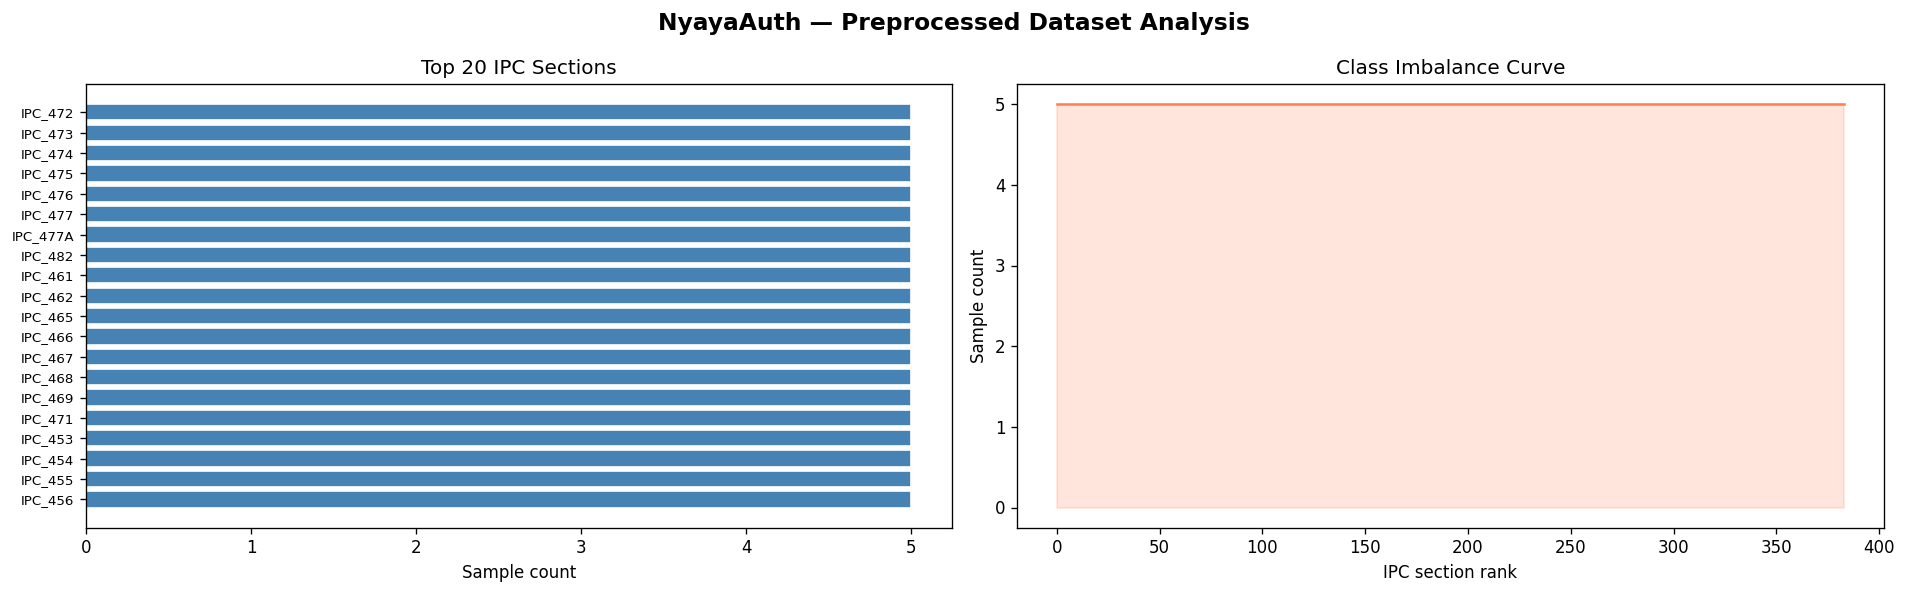

📊 Class imbalance summary (mirrors your paper):
   Top 10% sections cover : 9.9% of all samples
   Most common section    : IPC_472  (5 samples)
   Rarest section         : IPC_133  (5 samples)
   Imbalance ratio        : 1:1


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("NyayaAuth — Preprocessed Dataset Analysis", fontsize=14, fontweight='bold')

# Top 20 sections
top20 = dist.head(20)
axes[0].barh(top20.index[::-1], top20.values[::-1], color="steelblue", edgecolor="white")
axes[0].set_title("Top 20 IPC Sections")
axes[0].set_xlabel("Sample count")
axes[0].tick_params(axis='y', labelsize=8)

# Full distribution (imbalance curve)
axes[1].plot(range(len(dist)), dist.values, color="coral", linewidth=1.5)
axes[1].fill_between(range(len(dist)), dist.values, alpha=0.2, color="coral")
axes[1].set_title("Class Imbalance Curve")
axes[1].set_xlabel("IPC section rank")
axes[1].set_ylabel("Sample count")

plt.tight_layout()
plot_path = f"{OUT_DIR}/class_distribution_plot.png"
plt.savefig(plot_path, bbox_inches="tight")
plt.show()

# Imbalance stats matching your paper
top10_pct = dist.head(max(1, int(len(dist)*0.1))).sum() / len(df_aug) * 100
print(f"📊 Class imbalance summary (mirrors your paper):")
print(f"   Top 10% sections cover : {top10_pct:.1f}% of all samples")
print(f"   Most common section    : {dist.index[0]}  ({dist.iloc[0]} samples)")
print(f"   Rarest section         : {dist.index[-1]}  ({dist.iloc[-1]} samples)")
if dist.iloc[-1] > 0:
    print(f"   Imbalance ratio        : {dist.iloc[0]/dist.iloc[-1]:.0f}:1")

## Cell 11 — Final checklist ✅

In [12]:
required_files = {
    "train.csv"                 : "Training set",
    "val.csv"                   : "Validation set",
    "test.csv"                  : "Test set",
    "full_processed.csv"        : "Full processed dataset",
    "label_encoder.pkl"         : "Label encoder (IPC ↔ number)",
    "class_weights.npy"         : "Class weights (for imbalance)",
    "class_distribution.csv"    : "Class distribution report",
    "class_distribution_plot.png": "Distribution plot",
}

print("=" * 60)
print("  NyayaAuth — Preprocessing Complete — Final Checklist")
print("=" * 60)

all_ok = True
for fname, desc in required_files.items():
    path   = f"{OUT_DIR}/{fname}"
    exists = os.path.exists(path)
    size   = os.path.getsize(path)/1024 if exists else 0
    icon   = "✅" if exists else "❌"
    print(f"  {icon}  {fname:35s}  {size:7.1f} KB   ({desc})")
    if not exists:
        all_ok = False

# Dataset summary
train_df_chk = pd.read_csv(f"{OUT_DIR}/train.csv")
val_df_chk   = pd.read_csv(f"{OUT_DIR}/val.csv")
test_df_chk  = pd.read_csv(f"{OUT_DIR}/test.csv")

print(f"\n{'='*60}")
print(f"  📊 Dataset Summary")
print(f"{'='*60}")
print(f"  Total samples   : {len(df_aug)}")
print(f"  IPC sections    : {num_classes}")
print(f"  Train samples   : {len(train_df_chk)}")
print(f"  Val samples     : {len(val_df_chk)}")
print(f"  Test samples    : {len(test_df_chk)}")
print(f"  Columns         : {list(train_df_chk.columns)}")
print(f"{'='*60}")

if all_ok:
    print("\n🚀 Preprocessing done! Ready for Step 3 — Model Training.")
    print("   Your data is safe in:")
    print(f"   {OUT_DIR}")
else:
    print("\n⚠️  Some files missing. Re-run the cells marked ❌ above.")

  NyayaAuth — Preprocessing Complete — Final Checklist
  ✅  train.csv                             1615.3 KB   (Training set)
  ✅  val.csv                                207.6 KB   (Validation set)
  ✅  test.csv                               202.0 KB   (Test set)
  ✅  full_processed.csv                    2024.9 KB   (Full processed dataset)
  ✅  label_encoder.pkl                        4.3 KB   (Label encoder (IPC ↔ number))
  ✅  class_weights.npy                        1.6 KB   (Class weights (for imbalance))
  ✅  class_distribution.csv                   3.8 KB   (Class distribution report)
  ✅  class_distribution_plot.png             57.0 KB   (Distribution plot)

  📊 Dataset Summary
  Total samples   : 1920
  IPC sections    : 384
  Train samples   : 1536
  Val samples     : 192
  Test samples    : 192
  Columns         : ['description', 'ipc_section', 'clean_text', 'label']

🚀 Preprocessing done! Ready for Step 3 — Model Training.
   Your data is safe in:
   /content/drive/MyDrive/